## Transfer Learning with Tensorflow part 1: Feature Extraction

Transfer learning is leveraging a working model's existing architecture and learned patterns for our own problems.

There are two main benefits:
1. Can leverage an existing neural network architecture proven to work on problems similar to our own.
2. Can leverage a working neural network architecture which has already learned patterns on similar data to our own, then we can adapt those patterns to our own data.

# Become One With The Data

## Get the (10% of the 10 Food101)

In [ ]:
import  zipfile

# download the data
!wget https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_10_percent.zip

# Unzzip the downloaded file
zip_ref = zipfile.ZipFile("10_food_classes_10_percent.zip")
zip_ref.extractall()
zip_ref.close()

--2026-08-07 16:19:24--  https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_10_percent.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 142.251.121.207, 142.251.108.207, 192.178.142.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|142.251.121.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 168546183 (161M) [application/zip]
Saving to: ‘10_food_classes_10_percent.zip’

10_food_classes_10_ 100%[===================>] 160.74M   234MB/s    in 0.7s    

2026-08-07 16:19:25 (234 MB/s) - ‘10_food_classes_10_percent.zip’ saved [168546183/168546183]



In [ ]:
# Hoe many images in each folder
import os

# Walk through 10 percent data directory and list number of files
for dirpath, dirnames, filenames in os.walk("10_food_classes_10_percent/"):
  print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")

There are 2 directories and 0 images in '10_food_classes_10_percent/'.
There are 10 directories and 0 images in '10_food_classes_10_percent/train'.
There are 0 directories and 75 images in '10_food_classes_10_percent/train/grilled_salmon'.
There are 0 directories and 75 images in '10_food_classes_10_percent/train/hamburger'.
There are 0 directories and 75 images in '10_food_classes_10_percent/train/ramen'.
There are 0 directories and 75 images in '10_food_classes_10_percent/train/fried_rice'.
There are 0 directories and 75 images in '10_food_classes_10_percent/train/chicken_wings'.
There are 0 directories and 75 images in '10_food_classes_10_percent/train/pizza'.
There are 0 directories and 75 images in '10_food_classes_10_percent/train/sushi'.
There are 0 directories and 75 images in '10_food_classes_10_percent/train/steak'.
There are 0 directories and 75 images in '10_food_classes_10_percent/train/ice_cream'.
There are 0 directories and 75 images in '10_food_classes_10_percent/train/

## Creating data loaders (preparing the data)

We'll use the `ImageDataGenerator` class to load our images in batches.

In [ ]:
from IPython.core.display import Image

# Setup data inputs
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMAGE_SHAPE = (224,224)
BATCH_SIZE = 32

train_dir = "10_food_classes_10_percent/train"
test_dir = "10_food_classes_10_percent/test"

train_datagen = ImageDataGenerator(rescale = 1/255.)
test_datagen = ImageDataGenerator(rescale = 1/255.)

print("Training Images : ")
train_data_10_percent = train_datagen.flow_from_directory(train_dir,
                                                          target_size = IMAGE_SHAPE,
                                                          batch_size = BATCH_SIZE,
                                                          class_mode = "categorical")


print("Testing Images : ")
test_data_10_percent = test_datagen.flow_from_directory(test_dir,
                                                          target_size = IMAGE_SHAPE,
                                                          batch_size = BATCH_SIZE,
                                                          class_mode = "categorical")

Training Images : 
Found 750 images belonging to 10 classes.
Testing Images : 
Found 2500 images belonging to 10 classes.


# Setting Up Callbacks (Things to run whilst our model Trains)

Callbacks are extra functionality you can add to your models to be performed during or after training. Some of the most popular callbacks are:

*   Tracking experiments with the `TensorBoard` callback
*   Model checkpointing with the `ModelCheckpoint` callback
*   Stopping a model from training (before it trains too long and overfits) with the `EarlyStopping` callback

In [ ]:
# Create TensorBoard callbacks (functionized because we need to create a new one for each model)
import tensorflow as tf
import datetime

def create_tensorboard_callback(dir_name,experiment_name):
  log_dir = dir_name + "/" + experiment_name + "/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
  tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir = log_dir)
  print(f"Saving tensorboard log files to : {log_dir}")
  return tensorboard_callback

**Note** You can customize the directory where your TensorBoard logs (model training metrics are) get saved to whatever you like:

The `log_dir` parameter we've created above is only one option.

## Creating models using Tensorflow Hub

In the past, we've used TensorFlow to create our own models layer by layer from scratch.

Now we're going to do a similar process, except the majority of our model's layers are going to come from TensorFlow Hub.

We can access pre-trained models on [tfhub.dev](https://tfhub.dev/).

In [ ]:
# import dependencies
import tensorflow as tf
import tensorflow_hub as hub
from tensorflow.keras import layers


In [ ]:
import tensorflow as tf

try:
  resolver = tf.distribute.cluster_resolver.TPUClusterResolver()
  tf.config.experimental_connect_to_cluster(resolver)
  tf.tpu.experimental.initialize_tpu_system(resolver)
  strategy = tf.distribute.TPUStrategy(resolver)
  print("TPU initialized:", resolver.master())
except ValueError:
  print("TPU not found, using default strategy")
  strategy = tf.distribute.get_strategy()

TPU not found, using default strategy


In [ ]:
resnet_url = "https://tfhub.dev/google/imagenet/resnet_v2_50/feature_vector/4"
efficientnet_url = "https://tfhub.dev/google/imagenet/efficientnet_v2_imagenet1k_b0/feature_vector/2"

In [ ]:
def create_model(model_url , num_classes=10):
  '''
  Takes a TensorFlow Hub URL and creates a Keras Swquential model with to.

  Args:
    model_url (str): A TensorFLow Hub features Extraction URL
    num_classes (int): Number of output neurons in the output layers.
    should be equal to number of target classes, default 10.

    Returns:
    An uncompiled Keras Sequential model woth model_url
    as features extractor layer and dense output layers with num_classes outpit neurons.
  '''

  # Download the pretrained model and save it as a keras layer
  feature_extractor_layer = hub.KerasLayer(model_url,
                                           trainable=False, # freeze the already learned patterns
                                           name="feature_extractor_layer",
                                           input_shape = IMAGE_SHAPE+(3,))

  # create our own model
  model = tf.keras.Sequential([
      feature_extractor_layer,
      layers.Dense(num_classes,activation="softmax",name="output_layer")])

  return model

# Creating and testing google model

In [ ]:
import tensorflow as tf
import tensorflow_hub as hub
from tensorflow.keras import layers

# Define a custom wrapper layer to handle symbolic KerasTensors
class HubWrapperLayer(layers.Layer):
    def __init__(self, model_url, **kwargs):
        super(HubWrapperLayer, self).__init__(**kwargs)
        self.model_url = model_url
        self.hub_layer = hub.KerasLayer(model_url, trainable=False)

    def call(self, inputs):
        # In Keras 3, this ensures the symbolic tensor is handled by the underlying TF function
        return self.hub_layer(inputs)

    def get_config(self):
        config = super().get_config()
        config.update({"model_url": self.model_url})
        return config

def create_functional_model(model_url, num_classes=10):
    # Define Input layer
    inputs = layers.Input(shape=IMAGE_SHAPE + (3,), name="input_layer")

    # Use the wrapper to avoid the KerasTensor binding error
    x = HubWrapperLayer(model_url, name="feature_extraction_layer")(inputs)

    # Add output layer
    outputs = layers.Dense(num_classes, activation="softmax", name="output_layer")(x)

    # Construct model
    model = tf.keras.Model(inputs, outputs)
    return model

In [ ]:
# Create the functional model using the corrected function
model = create_functional_model(resnet_url,
                                num_classes=train_data_10_percent.num_classes)

# Display the model summary to confirm it works
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ feature_extraction_layer        │ (None, 2048)           │             0 │
│ (HubWrapperLayer)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │        20,490 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,490 (80.04 KB)

 Trainable params: 20,490 (80.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
with strategy.scope():
    model = create_functional_model(resnet_url, num_classes=train_data_10_percent.num_classes)
    model.compile(loss='categorical_crossentropy',
                  optimizer=tf.keras.optimizers.Adam(),
                  metrics=['accuracy'])

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ feature_extraction_layer        │ (None, 2048)           │             0 │
│ (HubWrapperLayer)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │        20,490 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,490 (80.04 KB)

 Trainable params: 20,490 (80.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(loss='categorical_crossentropy',
              optimizer=tf.keras.optimizers.Adam(),
              metrics=['accuracy']
              )


In [ ]:
# Re-fit the ResNet model to ensure model_history is available (it was interrupted previously)
print("Re-training ResNet model...")
model_history = model.fit(train_data_10_percent,
                          epochs=EPOCHS, # Using the defined EPOCHS constant
                          steps_per_epoch = len(train_data_10_percent),
                          validation_data=test_data_10_percent,
                          validation_steps = len(test_data_10_percent),
                          callbacks=[create_tensorboard_callback(dir_name='tensorflow_hub',
                                                                 experiment_name="resnet50_re_run")])
print("ResNet model re-training complete.")

Re-training ResNet model...
Saving tensorboard log files to : tensorflow_hub/resnet50_re_run/20260807-164917
Epoch 1/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 489s 21s/step - accuracy: 0.3467 - loss: 1.9879 - val_accuracy: 0.6064 - val_loss: 1.2313
Epoch 2/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 482s 20s/step - accuracy: 0.7360 - loss: 0.8992 - val_accuracy: 0.7264 - val_loss: 0.8669
Epoch 3/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 469s 20s/step - accuracy: 0.8280 - loss: 0.6303 - val_accuracy: 0.7668 - val_loss: 0.7459
Epoch 4/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 490s 21s/step - accuracy: 0.8747 - loss: 0.4808 - val_accuracy: 0.7776 - val_loss: 0.7154
Epoch 5/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 481s 20s/step - accuracy: 0.9147 - loss: 0.3798 - val_accuracy: 0.7912 - val_loss: 0.6756
ResNet model re-training complete.


In [ ]:
import matplotlib.pyplot as plt

# lets create afunction to plot our loss curves
# titbit you could put a function like this into a script called "helper.py" and call when you weant


# plot the validation and training curves

def plot_loss_curves(history):
  """
  return seprate loss curves for training and validation metrics
  """

  loss = history.history['loss']
  val_loss = history.history['val_loss']


  accuracy = history.history['accuracy']
  val_accuracy = history.history['val_accuracy']


  epochs = range(len(history.history["loss"]))


  # plot loss
  plt.plot(epochs, loss, label="training_loss")
  plt.plot(epochs, val_loss, label='val_loss')
  plt.title("Loss")
  plt.xlabel('epochs')
  plt.legend();

  # plot accuracy
  plt.figure()
  plt.plot(epochs, accuracy, label='training_accuracy')
  plt.plot(epochs, val_accuracy, label='val_accuracy')
  plt.title('Accuracy')
  plt.xlabel('Epochs')
  plt.legend()
  plt.show()

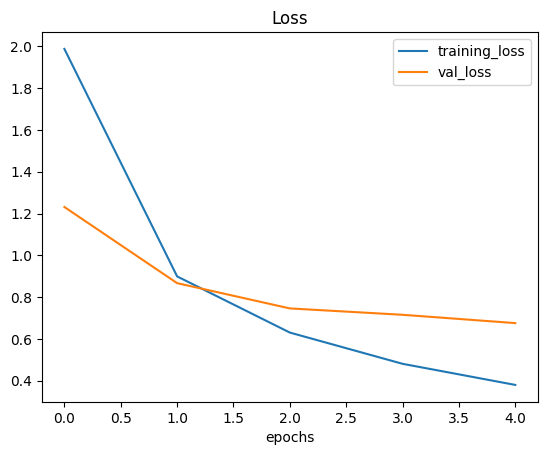

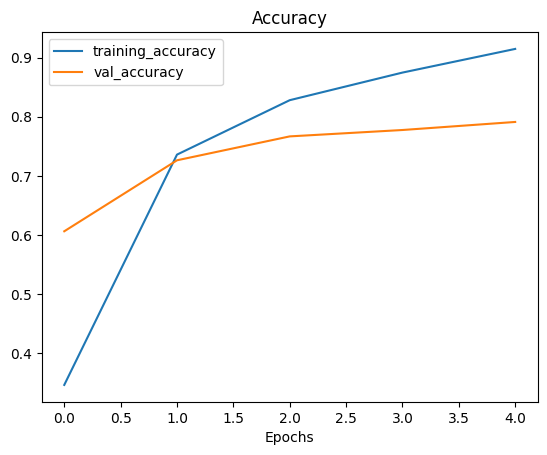

In [ ]:
plot_loss_curves(model_history)

# Creating and Testing Efficientnet extractor model

In [ ]:
efficientnet_model = create_functional_model(model_url=efficientnet_url,
                                  num_classes=train_data_10_percent.num_classes)

# compile efficent model
efficientnet_model.compile(loss='categorical_crossentropy',
                           optimizer=tf.keras.optimizers.Adam(),
                           metrics=['accuracy'])

EPOCHS = 5
# fit efficient model
efficcentnet_history = efficientnet_model.fit(train_data_10_percent,
                          epochs=5,
                          steps_per_epoch = len(train_data_10_percent),
                          validation_data=test_data_10_percent,
                          validation_steps = len(test_data_10_percent),
                          callbacks=[create_tensorboard_callback(dir_name='tensorflow_hub',
                                                                 experiment_name="efficientnetb0")])

Saving tensorboard log files to : tensorflow_hub/efficientnetb0/20260807-162008
Epoch 1/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 189s 8s/step - accuracy: 0.3507 - loss: 1.9981 - val_accuracy: 0.6240 - val_loss: 1.5132
Epoch 2/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 181s 8s/step - accuracy: 0.6933 - loss: 1.3061 - val_accuracy: 0.7112 - val_loss: 1.1182
Epoch 3/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 200s 8s/step - accuracy: 0.7720 - loss: 1.0057 - val_accuracy: 0.7416 - val_loss: 0.9420
Epoch 4/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 179s 7s/step - accuracy: 0.8107 - loss: 0.8390 - val_accuracy: 0.7596 - val_loss: 0.8495
Epoch 5/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 153s 7s/step - accuracy: 0.8400 - loss: 0.7300 - val_accuracy: 0.7756 - val_loss: 0.7888


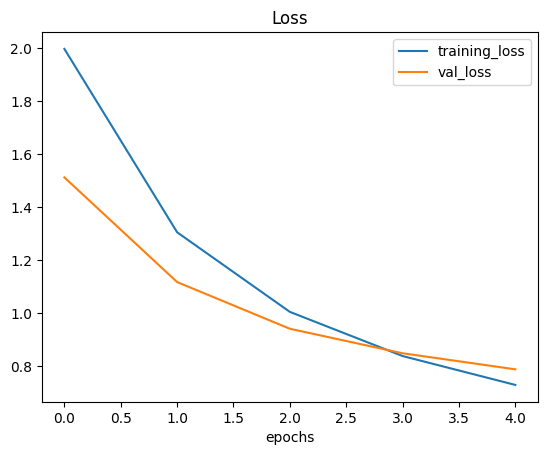

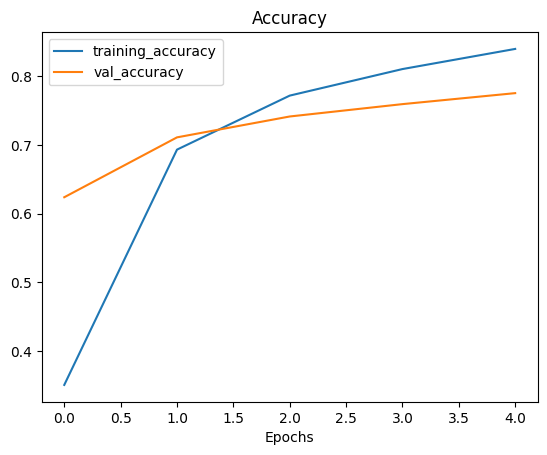

In [ ]:
plot_loss_curves(efficcentnet_history)

In [ ]:
efficientnet_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ feature_extraction_layer        │ (None, 1280)           │             0 │
│ (HubWrapperLayer)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,432 (150.13 KB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 25,622 (100.09 KB)

In [ ]:
# how many layers does our efficientnetb0 feature extractor have?

len(efficientnet_model.layers[2].weights)

2

## Different Types of Transfer Learning

*   `As-is` transfer learning: Using an existing model with no changes whatsoever (e.g., using an ImageNet model on 1000 ImageNet classes without any modifications).

*   `Feature extraction` transfer learning: Using the pre-learned patterns of an existing model (e.g., EfficientNetB0 trained on ImageNet) and adjusting the output layer for your own problem (e.g., classifying 10 classes of food).

*   `Fine-tuning` transfer learning: Using the pre-learned patterns of an existing model and fine-tuning many or all of the underlying layers (including the newly added output layer).

# Comparing Tensorboard HUB

> note when you upload things to tensorboard.dev you experiments are public so if you're running private experiment do not upload them to tensorboard

### Comparing ResNet50 and EfficientNetB0 Feature Extractors

Now that both models have been trained, let's visualize their loss and accuracy curves to compare their performance during training and validation.

Plotting loss curves for ResNet50 model:


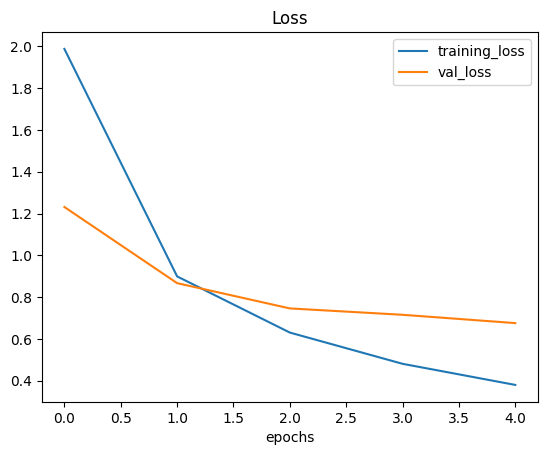

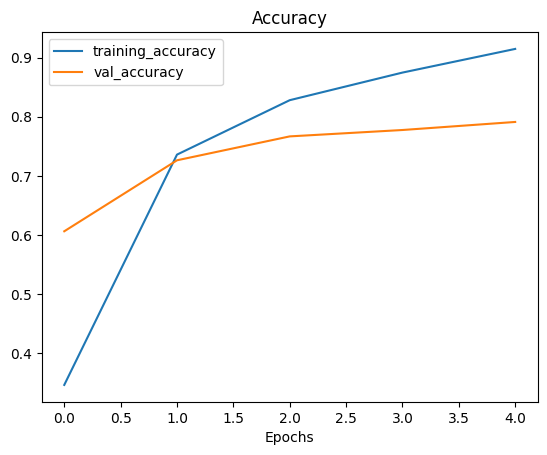

In [ ]:
print("Plotting loss curves for ResNet50 model:")
plot_loss_curves(model_history)

Plotting loss curves for EfficientNetB0 model:


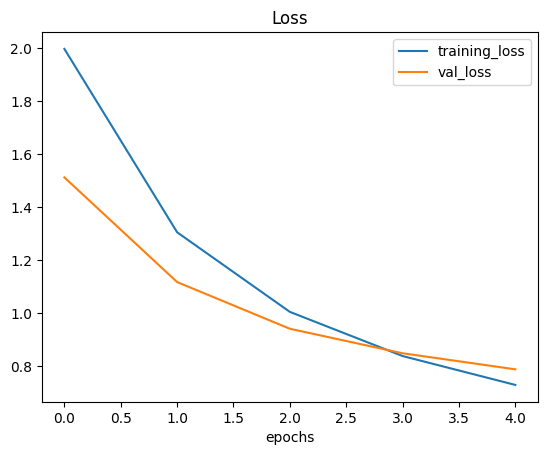

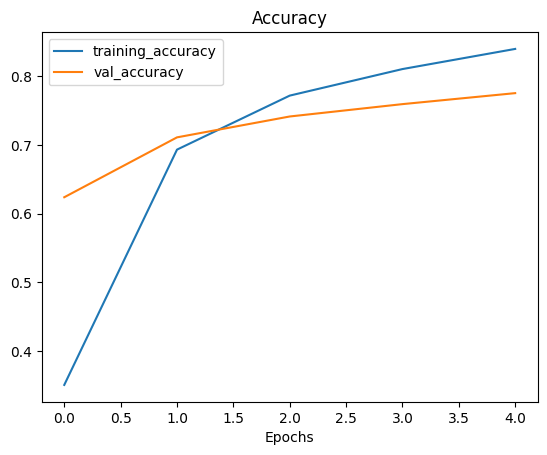

In [ ]:
print("Plotting loss curves for EfficientNetB0 model:")
plot_loss_curves(efficcentnet_history)

The error message `ERROR: The tensorboard dev command is no longer available.` indicates that `tensorboard.dev` has been shut down. You can no longer upload logs directly to `tensorboard.dev` for public viewing. If you wish to view your TensorBoard logs locally, you can still run `tensorboard --logdir ./tensorflow_hub/` in your terminal or a new Colab cell (prefixed with `!`).

### Model Comparison: ResNet50 vs. EfficientNetB0

Let's summarize the performance of both models using their final training and validation metrics.

In [ ]:
import pandas as pd

# Extract final metrics for ResNet50
resnet_train_loss = model_history.history['loss'][-1]
resnet_train_accuracy = model_history.history['accuracy'][-1]
resnet_val_loss = model_history.history['val_loss'][-1]
resnet_val_accuracy = model_history.history['val_accuracy'][-1]

# Extract final metrics for EfficientNetB0
efficientnet_train_loss = efficcentnet_history.history['loss'][-1]
efficientnet_train_accuracy = efficcentnet_history.history['accuracy'][-1]
efficientnet_val_loss = efficcentnet_history.history['val_loss'][-1]
efficientnet_val_accuracy = efficcentnet_history.history['val_accuracy'][-1]

# Create a DataFrame for comparison
comparison_df = pd.DataFrame({
    'Metric': ['Training Loss', 'Validation Loss', 'Training Accuracy', 'Validation Accuracy'],
    'ResNet50': [resnet_train_loss, resnet_val_loss, resnet_train_accuracy, resnet_val_accuracy],
    'EfficientNetB0': [efficientnet_train_loss, efficientnet_val_loss, efficientnet_train_accuracy, efficientnet_val_accuracy]
})

display(comparison_df.round(4))

,Metric,ResNet50,EfficientNetB0
0,Training Loss,0.3798,0.7300
1,Validation Loss,0.6756,0.7888
2,Training Accuracy,0.9147,0.8400
3,Validation Accuracy,0.7912,0.7756


From this table, you can compare the final performance metrics of both models to see which one performed better on your dataset.

### Side-by-Side Comparison of Loss and Accuracy Curves

To better understand the training dynamics, let's plot the loss and accuracy curves for both ResNet50 and EfficientNetB0 on a single figure.

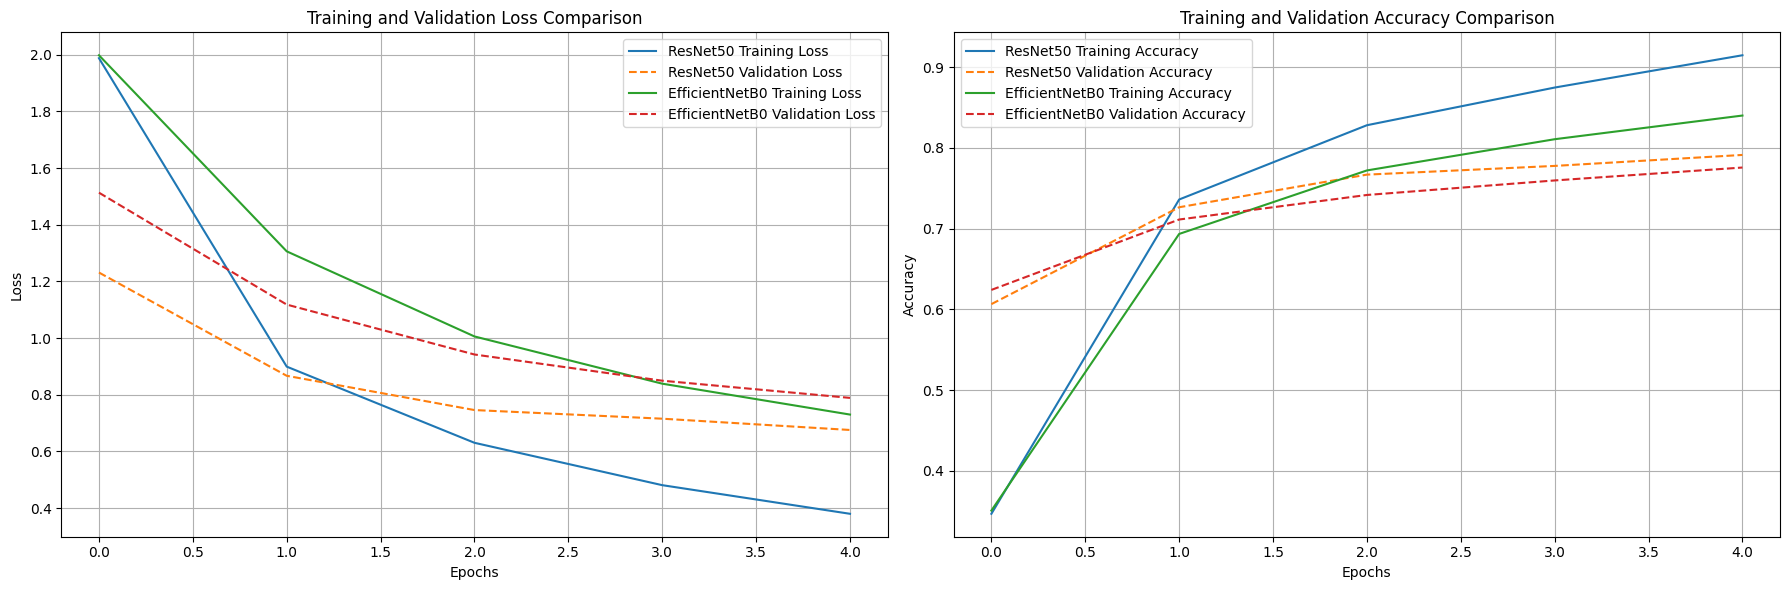

In [ ]:
import matplotlib.pyplot as plt

def plot_comparison_curves(history1, label1, history2, label2):
    """
    Plots loss and accuracy curves for two model histories side-by-side.
    """

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

    # Plot Loss
    ax1.plot(history1.history['loss'], label=f'{label1} Training Loss')
    ax1.plot(history1.history['val_loss'], label=f'{label1} Validation Loss', linestyle='--')
    ax1.plot(history2.history['loss'], label=f'{label2} Training Loss')
    ax1.plot(history2.history['val_loss'], label=f'{label2} Validation Loss', linestyle='--')
    ax1.set_title('Training and Validation Loss Comparison')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True)

    # Plot Accuracy
    ax2.plot(history1.history['accuracy'], label=f'{label1} Training Accuracy')
    ax2.plot(history1.history['val_accuracy'], label=f'{label1} Validation Accuracy', linestyle='--')
    ax2.plot(history2.history['accuracy'], label=f'{label2} Training Accuracy')
    ax2.plot(history2.history['val_accuracy'], label=f'{label2} Validation Accuracy', linestyle='--')
    ax2.set_title('Training and Validation Accuracy Comparison')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Accuracy')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

# Call the new comparison plotting function
plot_comparison_curves(model_history, 'ResNet50', efficcentnet_history, 'EfficientNetB0')